In [1]:
from FormUtils import pyForm, capture_physics_expr

In [2]:
%%pyForm ee_to_mumu

* Process: e+ e- -> mu+ mu- 

#include amplitude.inc

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha, Mass;

* Three momenta ratio in CM
Symbols pfInOutRatio;


Local M = (e^2 / s) * (VB(i1, p2, 0) * g(i1, i2, j1) * U(i2, p1, 0)) * (UB(i3, p3, Mass) * g(i3, i4, j1) * V(i4, p4, Mass));
#call squareamplitude(M, Msq)

.sort
trace4, 1;
trace4, 2;
.sort
contract;
Print Msq;
.sort

* Physics & Normalization
id e^4 = 16 * pi^2 * alpha^2;
* Spin averaging (1/2 * 1/2)
multiply 1/4; 

* 3. Kinematics 
* Repeat substitutions as needed.
* We form all Mandelstam 
* Note that here what happens
* is symbolic substitution

repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = Mass^2;
    id p4.p4 = Mass^2;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;
.sort

* Differential cross section formula
Local dSigma = (1 / (64 * pi^2 * s)) * pfInOutRatio * Msq;
.sort

bracket alpha, s, pfInOutRatio;
* Save
Format C;
#write <ee_to_mumu.txt> "%e;", dSigma;
.sort
* Print
Format;
factorize;
Print Msq;
Print dSigma;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr  8 17:43:11 2026
    
    * Process: e+ e- -> mu+ mu- 
    
    #include amplitude.inc
    *-------------------------------------------------------------------------*
    * amplitude.inc
    * Original Author: Jos Vermaseren (NIKHEF)
    * See also : J.A.M.Vermaseren "New features of FORM" math-ph/0010025
    *
    * Core Procedure: squareamplitude 
    * Description:
    * FORM procedure for squaring Feynman amplitudes, 
    * performing spin sums, and evaluating Dirac traces.
    *-------------------------------------------------------------------------*
    
    AutoDeclare Index i,j,k;
    AutoDeclare Symbol m,x;
    AutoDeclare Vector p,q;
    Vector q,q1,q2,p1,...,p10;
    CF  UB,U,VB,V,g,gstring,eps;
    CF  fprop,phprop,gprop,prop;
    Index k5=0, k6=0, k7=0;
    *
    *
    #procedure squareamplitude(Amp,Mat)
    .sort
    *
    *   We skip everything but Amp. In Amp we look for the highest i and j indices
    *
   

Captured Expression: pow(s,-3)*pow(alpha,2)*pow(Mass,4)*pfInOutRatio-pow(s,-3)*u*pow(alpha,2)*pow(Mass,2)*pfInOutRatio+1./2.*pow(s,-3)*pow(u,2)*pow(alpha,2)*pfInOutRatio-pow(s,-3)*t*pow(alpha,2)*pow(Mass,2)*pfInOutRatio+1./2.*pow(s,-3)*pow(t,2)*pow(alpha,2)*pfInOutRatio+pow(s,-2)*pow(alpha,2)*pow(Mass,2)*pfInOutRatio


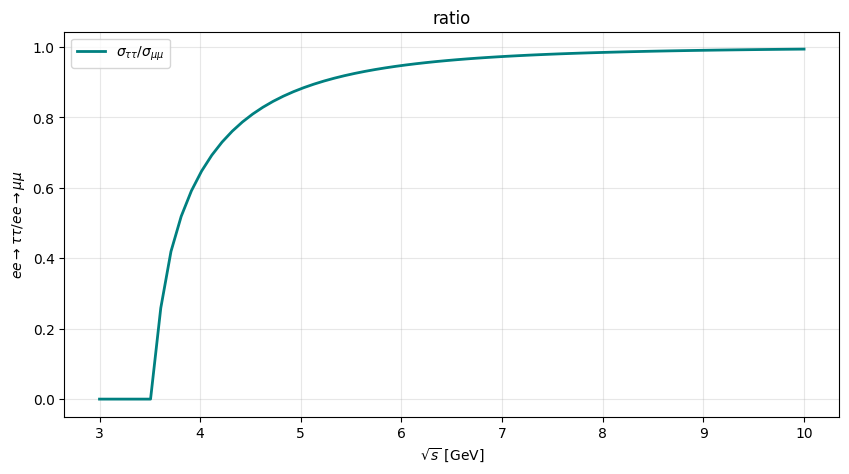

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from Kinematics import  kinematics2To2

plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True


# Capture 
form_expr = capture_physics_expr("scripts/ee_to_mumu.txt")
print(f"Captured Expression: {form_expr}")

mMuon = 0.10566
mTau = 1.7768
alpha = 1/137.036

angles = np.linspace(0, np.pi, 100)
cos_theta = np.cos(angles)
sqrtS_vals = np.linspace(3.0, 10.0, 70)
sigma_mu = []
sigma_tau = []

# 2. Integration Loop
for E in sqrtS_vals:
    # --- Muon Calculation ---
    s, t, u, r = kinematics2To2(E, angles, m3=mMuon, m4=mMuon)
    if E > 2 * mMuon:
        dsig_mu = eval(form_expr, {
            "s": s, "t": t, "u": u, 
            "alpha": alpha, "Mass": mMuon, 
            "pfInOutRatio": r,
            "pi" :np.pi,
        })
        # Integrate over d(cos theta)
        sigma_mu.append(simpson(dsig_mu, x=cos_theta))
    else:
        sigma_mu.append(np.nan)

    # --- Tau Calculation ---
    if E > 2 * mTau:
        s, t, u, r = kinematics2To2(E, angles, m3=mTau, m4=mTau)
        dsig_tau = eval(form_expr, {
            "s": s, "t": t, "u": u, 
            "alpha": alpha, "Mass": mTau, 
            "pfInOutRatio": r,
            "pi" :np.pi,
        })
        sigma_tau.append(simpson(dsig_tau, x=cos_theta))
    else:
        sigma_tau.append(0.0)

# 3. Compute Ratio
ratio_vals = np.array(sigma_tau) / np.array(sigma_mu)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(sqrtS_vals, ratio_vals, color='teal', lw=2, label=r'$\sigma_{\tau\tau}/\sigma_{\mu\mu}$')
plt.title("ratio")
plt.xlabel(r"$\sqrt{s}$ [GeV]")
plt.ylabel(r"$ ee \to \tau \tau / ee \to \mu \mu$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()